<a href="https://colab.research.google.com/github/prasa129/Econometrics/blob/main/ADF_Sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit Roots and Deterministic Trends

1-11-2026

A simulation to evaluate ADF test size and power under deterministic term misspecification for an autoregressive time series with a unit root.


#### Autoregressive Processes and Characteristic Roots

Let $y_t$ be a univariate time series following an autoregressive process of order $p$,

$$
y_t = \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t,
$$

where $\varepsilon_t$ is a zero-mean innovation process. The properties of $y_t$ are governed by the roots of the characteristic polynomial

$$
\Phi(z) = 1 - \phi_1 z - \phi_2 z^2 - \cdots - \phi_p z^p.
$$

If all roots of $ \Phi(z) = 0 $ lie outside the unit circle, the process is covariance stationary. If at least one root lies on the unit circle, the process is nonstationary. A unit root is a root equal to one. For an AR(1),

$$
y_t = \rho y_{t-1} + \varepsilon_t,
$$

the characteristic root is $z = \rho$. The process is stationary if $|\rho| < 1 $ and has a unit root if $ \rho = 1 $.



#### Unit Root and Stochastic Trends

When $ \rho = 1 $, the AR(1) process reduces to a random walk,

$$
y_t = y_{t-1} + \varepsilon_t,
$$

so that

$$
y_t = y_0 + \sum_{j=1}^{t} \varepsilon_j.
$$

Note that unlike a stationary process in which shocks are transitory, in a random walk shocks have a permanent effect and the variance of $y_t$ grows with $t$

$$
\text{Var}(y_t) = t\sigma^{2}_{\epsilon}.
$$

Many macroeconomic and financial time series display strong persistence, thus it is important to distinguish between highly persistent stationary processes ($ |\rho| \approx 1 $) and true unit root processes ($ \rho = 1 $).

#### Dickey-Fuller and Augmented Dickey-Fuller Tests

The Dickey--Fuller (DF) test is designed to test the null hypothesis of a unit root in the AR(1) model,

$$
H_0 : \rho = 1,
$$

against the alternative $ |\rho| < 1 $. Rewriting the AR(1) model in first differences gives

\begin{align*}
y_t &= \rho y_{t-1} + \varepsilon_t \\
y_t - y_{t-1} &= \rho y_{t-1} - y_{t-1} + \varepsilon_t \\
\Delta y_t &= (\rho - 1) y_{t-1} + \varepsilon_t.
\end{align*}

Let $ \alpha = \rho - 1 $. The null becomes $ H_0 : \alpha = 0 $. The DF test is based on the $t$-statistic for $\alpha$ in the regression

$$
\Delta y_t = \alpha y_{t-1} + \varepsilon_t.
$$

The ADF test extends this framework to allow for and thus control higher-order serial correlation by including lagged differences,

$$
\Delta y_t = \alpha y_{t-1} + \sum_{j=1}^{p} \psi_j \Delta y_{t-j} + \varepsilon_t.
$$

#### Deterministic Components and Trend Specification

In practice, many economic time series contain deterministic components such as constants and time trends. A general specification can be written as

$$
y_t = d_t + x_t,
$$

where $d_t$ is a deterministic component and $x_t$ is a stochastic component. Common choices for $d_t$ include:


\begin{aligned}
\text{no deterministic term:} \quad & d_t = 0, \\
\text{constant:} \quad & d_t = \mu, \\
\text{linear trend:} \quad & d_t = \mu + \beta t, \\
\text{quadratic trend:} \quad & d_t = \mu + \beta t + \gamma t^2.
\end{aligned}


The choice of deterministic specification and thus regression model for the ADF test is quite meaningful. Underfitting the deterministic component (e.g., omitting a trend when one is present) can lead to size distortions, while overfitting (e.g., including unnecessary trend terms) can reduce power. The asymptotic distribution of the ADF test statistic depends on the deterministic terms included in the regression, so misspecification directly affects inference.

With the aforementioned motivation, I perform a simluation study of how deterministic-term misspecification impacts the empirical size and power of the ADF test.

#### Simulation Design

The simulation study evaluates ADF test performance under controlled data generating processes (DGPs) that differ only in their deterministic structure. Let $ s = 1, \dots, T $ denote the analysis sample index. The deterministic component is defined as

$$
d_s = \mu + \beta s + \gamma s^2,
$$

with four regimes:


\begin{aligned}
\text{none:}  \quad & (\mu, \beta, \gamma) = (0, 0, 0), \\
\text{const:} \quad & (\mu \neq 0, \beta = 0, \gamma = 0), \\
\text{trend:} \quad & (\mu \neq 0, \beta \neq 0, \gamma = 0), \\
\text{quad:}  \quad & (\mu \neq 0, \beta \neq 0, \gamma \neq 0).
\end{aligned}

and origin fixed at $s = 1$ for all experiments.

#### Null DGP: Difference-Stationary with Deterministic Increments

Under the unit root null, the process is

$$
y_s = y_{s-1} + \Delta d_s + \varepsilon_s,
$$

where

$$
\Delta d_s = d_s - d_{s-1},
$$

and $\varepsilon_s$ are i.i.d. innovations with mean zero and variance $\sigma^2$. The initial condition $y_0$ is generated using burn-in,

$$
y_0 = \sum_{j=1}^{B} \varepsilon_j,
$$

with burn-in length $B$ with no deterministic drift, corresponding to a difference-stationary process with deterministic drift.



#### Alternative DGP: Trend-Stationary with AR(1) Errors

Under the stationary alternative, the process is

$$
y_s = d_s + u_s,
$$

where the stochastic component follows

$$
u_s = \rho u_{s-1} + \varepsilon_s, \quad |\rho| < 1.
$$

The initial state $u_0$ is generated using burn-in,

$$
u_0 = \sum_{j=1}^{B} \rho^{B-j} \varepsilon_j,
$$

so that $u_s$ is approximately stationary at the start of the sample, corresponding to a trend-stationary process with deterministic component $d_s$.

#### Innovation Structure

Innovations $\varepsilon_s$ are either Gaussian

$$
\varepsilon_s \sim \mathcal{N}(0, \sigma^2),
$$

or scaled Student-$t$ innovations with $\nu > 2$ degrees of freedom,

$$
\varepsilon_s = \sigma \cdot \frac{t_{\nu}}{\sqrt{\nu / (\nu - 2)}}.
$$

The baseline specification uses Gaussian innovations.

#### ADF Regression Specifications

For each simulated series, I apply the ADF test using the following regression specifications:

$$
\texttt{n}, \quad \texttt{c}, \quad \texttt{ct}, \quad \texttt{ctt},
$$

corresponding respectively to:

\begin{aligned}
\texttt{n}  &: \text{no constant, no trend}, \\
\texttt{c}  &: \text{constant only}, \\
\texttt{ct} &: \text{constant and linear trend}, \\
\texttt{ctt}&: \text{constant, linear trend, and quadratic trend}.
\end{aligned}

To keep the experiment size feasible, I control lag length using fixed values $ p \in \{0,1,2\} $.


#### Experimental Grid and Evaluation Metrics

The simulation design varies over:

$$
T \in \{100, 250\},
$$

$$
\rho \in \{0.90, 0.95, 0.98, 0.99\},
$$

and all four deterministic regimes $ \{ \text{none}, \text{const}, \text{trend}, \text{quad} \} $. I evaluate each design point using $ N = 300 $ Monte Carlo replications. For each design, the rejection frequency is

$$
\hat{p} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}\{ \text{ADF rejects in replication } i \}.
$$

with Monte Carlo standard errors

$$
\text{MCSE}(\hat{p}) = \sqrt{ \frac{\hat{p}(1 - \hat{p})}{N} }.
$$

Under the null DGP, $\hat{p}$ measures empirical size. Under the alternative DGP, $\hat{p}$ measures power.

#### Correct and Misspecified Deterministic Structure

Using Statsmodels ADF test, for each deterministic regime, the implied correct ADF specification is

$$
\text{none} \rightarrow \texttt{n}, \quad
\text{const} \rightarrow \texttt{c}, \quad
\text{trend} \rightarrow \texttt{ct}, \quad
\text{quad} \rightarrow \texttt{ctt}.
$$

I analyze results both by individual specification and by grouping into correctly specified and misspecified cases.

In [1]:
# minimal imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller



def draw_innovations(rng, T, innov, sigma, t_df):
    """
    Draw i.i.d. innovations for the simulation.

    Args:
    -----
        rng (numpy random Generator) : random number generator
        T (int) : number of draws
        innov (str) : "normal" or "t"
        sigma (float) : innovation scale (target sd)
        t_df (int) : degrees of freedom for t innovations (must be > 2)

    Returns:
    --------
        eps (ndarray) : innovations of length T
    """

    # if normal innovations, draw n(0, sigma^2)
    if innov == "normal":

        # draw normal innovations
        eps = rng.normal(loc=0.0, scale=sigma, size=T)

        # return innovations
        return eps


    # if t innovations, scale to have variance sigma^2
    if innov == "t":

        # draw standard t innovations
        x = rng.standard_t(df=t_df, size=T)

        # compute scaling for variance matching (df>2 required)
        scale = sigma / np.sqrt(t_df / (t_df - 2))

        # scale t draws
        eps = scale * x

        # return innovations
        return eps


    # if invalid innovation type, raise error
    raise ValueError("innov must be 'normal' or 't'.")



def adf_reject(y, regression, alpha, maxlag, autolag):
    """
    Run adf test and return a rejection indicator at significance level alpha.

    Args:
    -----
        y (ndarray) : input series
        regression (str) : one of {"n","c","ct","ctt"}
        alpha (float) : significance level
        maxlag (int or None) : fixed lag if not none
        autolag (str or None) : autolag criterion ("aic" or "bic") if not none

    Returns:
    --------
        reject (int) : 1 if reject h0 (unit root), else 0
    """

    # compute adf result tuple
    res = adfuller(y, maxlag=maxlag, regression=regression, autolag=autolag)

    # extract p-value
    pval = res[1]

    # convert to integer reject indicator
    reject = int(pval < alpha)

    # return indicator
    return reject



def run_adf_mc(nrep=2000, seed=123, alpha=0.05, T_list=(50, 100, 250, 500),
               rho_list=(0.8, 0.9, 0.95, 0.98, 0.99), mu=1.0, beta=0.02,
               gamma=0.0002, innov="normal", t_df=5, sigma=1.0, burn=200,
               regressions=("n", "c", "ct", "ctt"), fixed_lags=(0, 1, 2, 4),
               autolags=("AIC", "BIC")):
    """
    Monte Carlo study for ADF size and power under DF aligned dgps.

    Data generating processes:
    ----
    h0 (unit root / difference-stationary with deterministic increments):
        y_s = y_{s-1} + Δd_s + ε_s

    h1 (trend-stationary):
        y_s = d_s + u_s
        u_s = rho u_{s-1} + ε_s

    deterministic cases
    -------------------
    none  : d_s = 0
    const : d_s = mu
    trend : d_s = mu + beta*s
    quad  : d_s = mu + beta*s + gamma*s^2

    Args:
    -----
        nrep (int) : number of monte carlo replications
        seed (int) : random seed
        alpha (float) : test size
        T_list (tuple[int]) : sample sizes
        rho_list (tuple[float]) : ar(1) coefficients for h1
        mu (float) : constant term magnitude
        beta (float) : linear trend magnitude
        gamma (float) : quadratic trend magnitude
        innov (str) : "normal" or "t"
        t_df (int) : degrees of freedom for t innovations
        sigma (float) : innovation scale
        burn (int) : burn-in length for stochastic state
        regressions (tuple[str]) : adf regression flags
        fixed_lags (tuple[int]) : fixed lag lengths
        autolags (tuple[str]) : autolag criteria

    Returns:
    --------
        df (pandas DataFrame) : monte carlo results table
    """

    # create rng
    rng = np.random.default_rng(seed)

    # define deterministic cases
    det_cases = ("none", "const", "trend", "quad")

    # create list to store rows
    rows = []

    # loop over sample sizes
    for T in T_list:

        # precompute s index for analysis sample
        s = np.arange(1, T + 1)

        # precompute d(s) for each deterministic case
        d_map = {}

        # loop over deterministic cases
        for det_case in det_cases:

            # if no deterministic term, set zeros
            if det_case == "none":

                # build deterministic component
                d = 0.0 + 0.0 * s

            # if constant only
            if det_case == "const":

                # build deterministic component
                d = mu + 0.0 * s

            # if linear trend
            if det_case == "trend":

                # build deterministic component
                d = mu + beta * s

            # if quadratic trend
            if det_case == "quad":

                # build deterministic component
                d = mu + beta * s + gamma * (s ** 2)

            # store in map
            d_map[det_case] = d


        # -------------------------
        # H0: size (unit root)
        # -------------------------

        # loop over deterministic cases
        for det_case in det_cases:

            # pull deterministic component d(s)
            d = d_map[det_case]

            # compute d(0) consistent with same formula
            if det_case == "none":
                d0 = 0.0
            if det_case == "const":
                d0 = mu
            if det_case == "trend":
                d0 = mu + beta * 0.0
            if det_case == "quad":
                d0 = mu + beta * 0.0 + gamma * (0.0 ** 2)

            # compute delta d(s) = d(s) - d(s-1)
            delta_d = d - np.r_[d0, d[:-1]]


            # loop over adf regressions
            for regression in regressions:

                # loop over fixed lags
                for p in fixed_lags:

                    # initialize rejection counter
                    rejects = 0

                    # repeat monte carlo reps
                    for _ in range(nrep):

                        # draw burn-in innovations for y0
                        eps_burn = draw_innovations(rng, burn, innov, sigma, t_df)

                        # construct y0 as random-walk burn-in state
                        y_prev = eps_burn.sum()

                        # draw sample innovations
                        eps = draw_innovations(rng, T, innov, sigma, t_df)

                        # allocate y
                        y = np.empty(T)

                        # iterate random walk with deterministic increments
                        for i in range(T):

                            # update y_t = y_{t-1} + Δd_t + ε_t
                            y[i] = y_prev + delta_d[i] + eps[i]

                            # advance state
                            y_prev = y[i]

                        # run adf rejection
                        rejects += adf_reject(y, regression, alpha, maxlag=p, autolag=None)

                    # compute rejection rate
                    phat = rejects / nrep

                    # compute mc se
                    se = np.sqrt(phat * (1.0 - phat) / nrep)

                    # append result row
                    rows.append({"truth": "H0_unit_root","T": T,"det_case": det_case,
                                 "rho": np.nan,"adf_regression": regression,"lag_method": f"fixed_{p}",
                                 "reject_rate": phat,"mc_se": se,"nrep": nrep})


                # loop over autolag criteria
                for a in autolags:

                    # initialize rejection counter
                    rejects = 0

                    # repeat monte carlo reps
                    for _ in range(nrep):

                        # draw burn-in innovations for y0
                        eps_burn = draw_innovations(rng, burn, innov, sigma, t_df)

                        # construct y0 as random-walk burn-in state
                        y_prev = eps_burn.sum()

                        # draw sample innovations
                        eps = draw_innovations(rng, T, innov, sigma, t_df)

                        # allocate y
                        y = np.empty(T)

                        # iterate random walk with deterministic increments
                        for i in range(T):

                            # update y_t = y_{t-1} + Δd_t + ε_t
                            y[i] = y_prev + delta_d[i] + eps[i]

                            # advance state
                            y_prev = y[i]

                        # run adf rejection
                        rejects += adf_reject(y, regression, alpha, maxlag=None, autolag=a)

                    # compute rejection rate
                    phat = rejects / nrep

                    # compute mc se
                    se = np.sqrt(phat * (1.0 - phat) / nrep)

                    # append result row
                    rows.append({"truth": "H0_unit_root","T": T,"det_case": det_case,
                                 "rho": np.nan,"adf_regression": regression,"lag_method": f"autolag_{a}",
                                 "reject_rate": phat,"mc_se": se,"nrep": nrep})


        # -------------------------
        # H1: power (trend-stationary)
        # -------------------------

        # loop over rho values
        for rho in rho_list:

            # loop over deterministic cases
            for det_case in det_cases:

                # pull deterministic component d(s)
                d = d_map[det_case]


                # loop over adf regressions
                for regression in regressions:

                    # loop over fixed lags
                    for p in fixed_lags:

                        # initialize rejection counter
                        rejects = 0

                        # repeat monte carlo reps
                        for _ in range(nrep):

                            # draw burn-in innovations for u0
                            eps_burn = draw_innovations(rng, burn, innov, sigma, t_df)

                            # initialize u
                            u = 0.0

                            # burn-in u to approximate stationarity
                            for e in eps_burn:

                                # update u
                                u = rho * u + e

                            # set initial u state
                            u_prev = u

                            # draw sample innovations
                            eps = draw_innovations(rng, T, innov, sigma, t_df)

                            # allocate u path
                            u_path = np.empty(T)

                            # iterate stationary AR(1)
                            for i in range(T):

                                # update u_t
                                u_path[i] = rho * u_prev + eps[i]

                                # advance state
                                u_prev = u_path[i]

                            # construct y = d + u
                            y = d + u_path

                            # run adf rejection
                            rejects += adf_reject(y, regression, alpha, maxlag=p, autolag=None)

                        # compute rejection rate
                        phat = rejects / nrep

                        # compute mc se
                        se = np.sqrt(phat * (1.0 - phat) / nrep)

                        # append result row
                        rows.append({"truth": "H1_trend_stationary","T": T,"det_case": det_case,
                                     "rho": rho,"adf_regression": regression,"lag_method": f"fixed_{p}",
                                     "reject_rate": phat,"mc_se": se,"nrep": nrep})


                    # loop over autolag criteria
                    for a in autolags:

                        # initialize rejection counter
                        rejects = 0

                        # repeat monte carlo reps
                        for _ in range(nrep):

                            # draw burn-in innovations for u0
                            eps_burn = draw_innovations(rng, burn, innov, sigma, t_df)

                            # initialize u
                            u = 0.0

                            # burn-in u to approximate stationarity
                            for e in eps_burn:

                                # update u
                                u = rho * u + e

                            # set initial u state
                            u_prev = u

                            # draw sample innovations
                            eps = draw_innovations(rng, T, innov, sigma, t_df)

                            # allocate u path
                            u_path = np.empty(T)

                            # iterate stationary ar(1)
                            for i in range(T):

                                # update u_t
                                u_path[i] = rho * u_prev + eps[i]

                                # advance state
                                u_prev = u_path[i]

                            # construct y = d + u
                            y = d + u_path

                            # run adf rejection
                            rejects += adf_reject(y, regression, alpha, maxlag=None, autolag=a)

                        # compute rejection rate
                        phat = rejects / nrep

                        # compute mc se
                        se = np.sqrt(phat * (1.0 - phat) / nrep)

                        # append result row
                        rows.append({"truth": "H1_trend_stationary","T": T,"det_case": det_case,
                                     "rho": rho,"adf_regression": regression,"lag_method": f"autolag_{a}",
                                     "reject_rate": phat,"mc_se": se,"nrep": nrep})


    # convert to dataframe
    df = pd.DataFrame(rows)

    # add implied correct regression per deterministic case
    df["correct_regression"] = df["det_case"].map({"none": "n",
                                                   "const": "c",
                                                   "trend": "ct",
                                                   "quad": "ctt"})

    # flag correct specification
    df["is_correct_spec"] = (df["adf_regression"] == df["correct_regression"])

    # return results
    return df



# run experiment with fixed lags for speed
df = run_adf_mc(nrep=300, T_list=(100, 250), rho_list=(0.9, 0.95, 0.98, 0.99),
                fixed_lags=(0, 1, 2), autolags=())

# check results
display(df)

,truth,T,det_case,rho,adf_regression,lag_method,reject_rate,mc_se,nrep,correct_regression,is_correct_spec
0,H0_unit_root,100,none,NaN,n,fixed_0,0.043333,0.011755,300,n,True
1,H0_unit_root,100,none,NaN,n,fixed_1,0.046667,0.012178,300,n,True
2,H0_unit_root,100,none,NaN,n,fixed_2,0.053333,0.012973,300,n,True
3,H0_unit_root,100,none,NaN,c,fixed_0,0.043333,0.011755,300,n,False
4,H0_unit_root,100,none,NaN,c,fixed_1,0.053333,0.012973,300,n,False
...,...,...,...,...,...,...,...,...,...,...,...
475,H1_trend_stationary,250,quad,0.99,ct,fixed_1,0.043333,0.011755,300,ctt,False
476,H1_trend_stationary,250,quad,0.99,ct,fixed_2,0.053333,0.012973,300,ctt,False
477,H1_trend_stationary,250,quad,0.99,ctt,fixed_0,0.053333,0.012973,300,ctt,True
478,H1_trend_stationary,250,quad,0.99,ctt,fixed_1,0.063333,0.014062,300,ctt,True


The full Monte Carlo design and results across all combinations of sample size T, deterministic regime, ADF regression, and $\rho$ are above. Each row reports the empirical rejection frequency (reject_rate) and its Monte Carlo standard error (mc_se) based on 300 replications, under either the unit root null (H0_unit_root, measuring size) or the trend-stationary alternative (H1_trend_stationary, measuring power). The columns correct_regression and is_correct_spec indicate the implied correct deterministic specification for each DGP and whether the ADF regression is correctly specified.

To interpret the results, I present size heatmaps which collapse null results by $T$, regime, and ADF specification, and power plots which show rejection rates as functions of $\rho$ across deterministic regimes and sample sizes.


#### Size Heatmaps

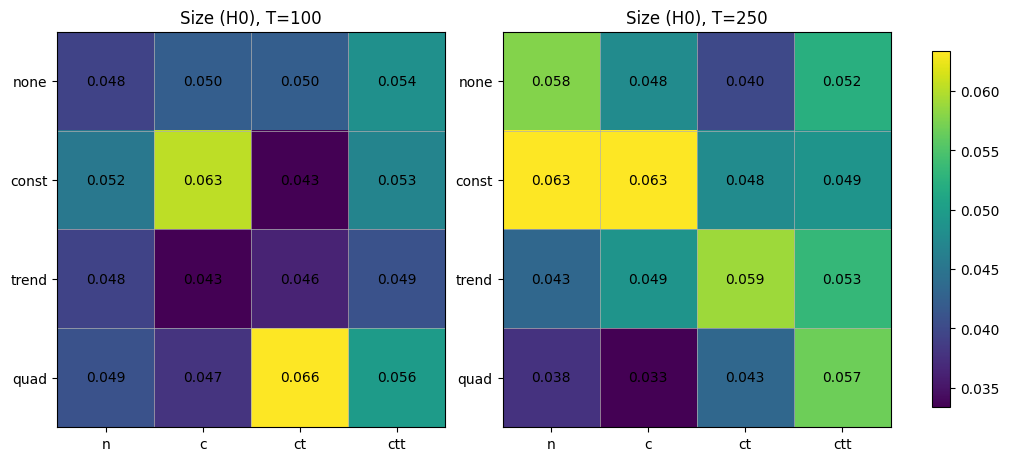

In [2]:
# keep a copy
df0 = df.copy()

# filter to h0 only (size) and h1 only (power)
df_h0 = df0[df0["truth"] == "H0_unit_root"].copy()
df_h1 = df0[df0["truth"] == "H1_trend_stationary"].copy()

# build size and power summary by averaging over lag method
size_summary = (df_h0.groupby(["T", "det_case", "adf_regression"])["reject_rate"].mean().reset_index())
power_summary = (df_h1.groupby(["T", "det_case", "rho", "adf_regression"])["reject_rate"].mean().reset_index())

# pull unique sorted values for plotting layouts
T_vals = sorted(df0["T"].dropna().unique().tolist())

# define det case order explicitly for subplot layout
det_order = ["none", "const", "trend", "quad"]

# keep only det cases that actually exist in results
det_cases = [x for x in det_order if x in df0["det_case"].unique().tolist()]

# define adf regression order
reg_order = ["n", "c", "ct", "ctt"]

# keep only regressions that exist
regressions = [x for x in reg_order if x in df0["adf_regression"].unique().tolist()]

# set up figure with 1 row and len(T_vals) columns
fig1, axes1 = plt.subplots(nrows=1, ncols=len(T_vals), figsize=(5.0 * len(T_vals), 4.5), constrained_layout=True)

# handle case when matplotlib returns a single axis
if len(T_vals) == 1: axes1 = [axes1]

# loop over sample sizes for heatmaps
for j, T0 in enumerate(T_vals):

    # subset size summary for this T
    tmp = size_summary[size_summary["T"] == T0].copy()

    # pivot to det_case x regression
    mat = tmp.pivot_table(index="det_case",columns="adf_regression",values="reject_rate")

    # reindex to stable order
    mat = mat.reindex(index=det_cases, columns=regressions)

    # convert to numpy array for imshow
    Z = mat.to_numpy()

    # draw heatmap
    im = axes1[j].imshow(Z, aspect="auto", interpolation="nearest")

    # set title, ticks, labels
    axes1[j].set_title(f"Size (H0), T={T0}")
    axes1[j].set_xticks(np.arange(len(regressions)))
    axes1[j].set_xticklabels(regressions)
    axes1[j].set_yticks(np.arange(len(det_cases)))
    axes1[j].set_yticklabels(det_cases)

    # add gridlines using minor ticks
    axes1[j].set_xticks(np.arange(-0.5, len(regressions), 1), minor=True)
    axes1[j].set_yticks(np.arange(-0.5, len(det_cases), 1), minor=True)
    axes1[j].grid(which="minor", linestyle="-", linewidth=0.5)
    axes1[j].tick_params(which="minor", bottom=False, left=False)

    # annotate cells with values
    for r in range(Z.shape[0]):

        # loop over columns
        for c in range(Z.shape[1]):

            # skip nan
            if np.isnan(Z[r, c]):
                continue

            # write value
            axes1[j].text(c, r, f"{Z[r, c]:.3f}", ha="center", va="center")



# add a colorbar and plot
fig1.colorbar(im, ax=axes1, shrink=0.9)
plt.show()



The size results show clear distortions driven by deterministic-term misspecification. When the deterministic structure is correctly specified, empirical size is generally close to the nominal 5% level across both sample sizes. In contrast, underfitting the deterministic component leads to size inflation, most notably when a constant or trend is present in the DGP but omitted in the ADF regression (e.g., using n or c when the true process contains a trend), with rejection rates rising to the 6–6.5$\%$ range. Conversely, overfitting the deterministic component makes the test more conservative, particularly when quadratic trends are unnecessarily included, yielding rejection rates as low as 3–4$\%$. These effects become more pronounced at T=250.


#### Power Curves

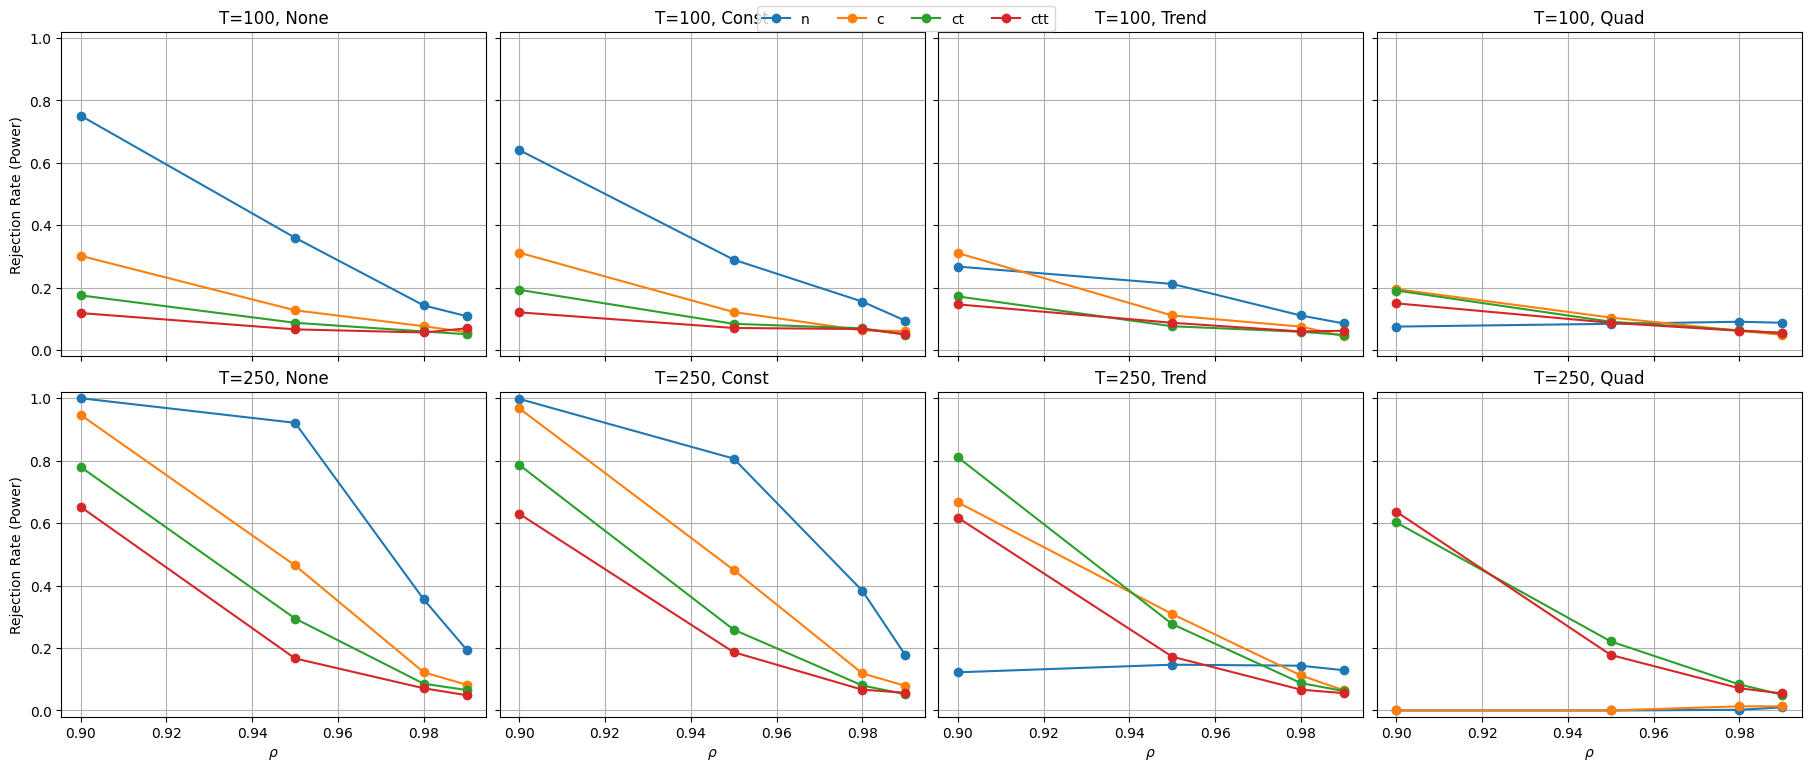

In [3]:
# set up figure with rows=len(T_vals) and cols=len(det_cases)
fig2, axes2 = plt.subplots(nrows=len(T_vals),ncols=len(det_cases),figsize=(4.5 * len(det_cases), 3.8 * len(T_vals)),constrained_layout=True,sharex=True,sharey=True)

# make axes2 2d
if len(T_vals) == 1 and len(det_cases) == 1:

    # wrap as 2d
    axes2 = np.array([[axes2]])

elif len(T_vals) == 1:

    # wrap as 2d
    axes2 = np.array([axes2])

elif len(det_cases) == 1:

    # wrap as 2d
    axes2 = np.array([[ax] for ax in axes2])



# loop over rows (T)
for i, T0 in enumerate(T_vals):

    # loop over columns (det_case)
    for j, det0 in enumerate(det_cases):

        # select axis
        ax = axes2[i, j]

        # subset power summary
        tmp = power_summary[(power_summary["T"] == T0) & (power_summary["det_case"] == det0)].copy()

        # loop over adf regressions
        for reg in regressions:

            # subset
            sub = tmp[tmp["adf_regression"] == reg].copy()

            # skip empty
            if sub.shape[0] == 0:
                continue

            # sort by rho for proper line plotting
            sub = sub.sort_values("rho")

            # plot line
            ax.plot(sub["rho"], sub["reject_rate"], marker="o", label=reg)

        # set title, limits, grid
        ax.set_title(f"T={T0}, {det0.capitalize()}")
        ax.set_ylim(-0.02, 1.02)
        ax.grid(True)

# label x-axis for bottom row
for j in range(len(det_cases)):

    # set xlabel
    axes2[-1, j].set_xlabel(r"$\rho$")

# label y-axis for left column
for i in range(len(T_vals)):

    # set ylabel
    axes2[i, 0].set_ylabel("Rejection Rate (Power)")



# build a single legend using handles from the first subplot that has lines
handles = None
labels = None

# search for a subplot with plotted lines
for i in range(len(T_vals)):

    # loop over det_cases
    for j in range(len(det_cases)):

        # get legend items
        h, l = axes2[i, j].get_legend_handles_labels()

        # if found, store and break
        if len(h) > 0:
            handles = h
            labels = l
            break

    # break outer if found
    if handles is not None:
        break

# add global legend if found
if handles is not None:

    # place legend above plots
    fig2.legend(handles, labels, loc="upper center", ncol=len(labels))

# show figure
plt.show()


With the correct deterministic structure, power is high even for moderately persistent alternatives, and rises sharply with T. In contrast, overfitting deterministic components degrades test power. Including unnecessary trend or quadratic terms (e.g., using ct or ctt when the true process is none or const)in some cases drives rejection rates close to zero even at T=250 and $\rho=0.90$. Underfitting deterministic terms also reduces power, although the effect is less pronounced, as seen when trend-stationary processes are tested with n or c. Note that increasing sample size magnifies the distortion. Power for correctly specified models approaches one, while misspecified models remain persistently weak.

#### Conclusions

I conclude with the following observations.

1. Deterministic specification is a first-order identification issue, not a cosmetic modeling choice. Getting the deterministic component wrong can dominate the effect of sample size, persistence, and lag selection. In several panels, misspecification renders the ADF test nearly uninformative even when T is large and $\rho$ is far from unity.

2. Overfitting deterministic terms is more damaging than underfitting.
While omitting a true trend inflates size and reduces power, including unnecessary trend or quadratic terms often collapses power to near zero. This asymmetry is actually quite important. The practice of “being safe” by adding trends can destroy the test.

3. Size distortions persist and are magnified with sample size. The heatmaps show that misspecification effects do not wash out as T increases, if anything, they become more pronounced. Large samples do not simply “fix” unit root testing problems.

4. Correct specification yields great performance. In the correctly specified cases, power rises rapidly toward one as T increases and $\rho$ moves away from unity, exactly as theory predicts. The ADF test itself is not inherently suspect, but it is implicitly a joint test of stochastic and deterministic structure. The test is not simply asking “is there a unit root?” but “is there a unit root conditional on a specific deterministic structure?”.

5. Observed power losses are economically large, not just statistically noticeable. In several misspecified cases, power at $\rho=0.90$ and $T=250$ is lower than power at $\rho=0.99$ under correct specification. Empirical conclusions about persistence can be reversed purely by deterministic misclassification.

6. Since real macro and financial series rarely have clean, known deterministic structure, applied unit root testing has misspecification error and in that regard, unit root testing for economic data is fundamentally fragile.